# 1.3 – MNIST Autoencoder Evaluation

Loads the pre-trained `ConvAutoencoder` (VAE, `latent_dim=3`) from its Lightning checkpoint, evaluates reconstruction quality, and visualises the learned latent space.

In [1]:
import sys
sys.path.insert(0, "../src")

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA

from models.ae_channels import ConvAutoencoder
from training.lit_autoencoder import LitAutoencoder

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT = "../checkpoints/autoencoder/last-v11.ckpt"
DATA_DIR = "../data"
LATENT_DIM = 3
print(f"Using device: {DEVICE}")

Using device: cuda


## Load model from Lightning checkpoint

In [2]:
lit = LitAutoencoder.load_from_checkpoint(CHECKPOINT, model=ConvAutoencoder(latent_dim=LATENT_DIM))
ae = lit.model.to(DEVICE).eval()
n_params = sum(p.numel() for p in ae.parameters())
print(f"ConvAutoencoder loaded — {n_params:,} parameters, latent_dim={LATENT_DIM}")

ConvAutoencoder loaded — 96,407 parameters, latent_dim=3


## Reconstruction quality

In [35]:
test_ds = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=4)

total_mse = 0.0
with torch.no_grad():
    for x, _ in test_loader:
        _, _, recon = ae(x.to(DEVICE))
        total_mse += torch.nn.functional.mse_loss(recon, x.to(DEVICE), reduction="sum").item()

mean_mse = total_mse / len(test_ds)
print(f"Mean per-image MSE on test set: {mean_mse:.6f}")

Mean per-image MSE on test set: 20.412385


## Reconstructions — original vs. decoded

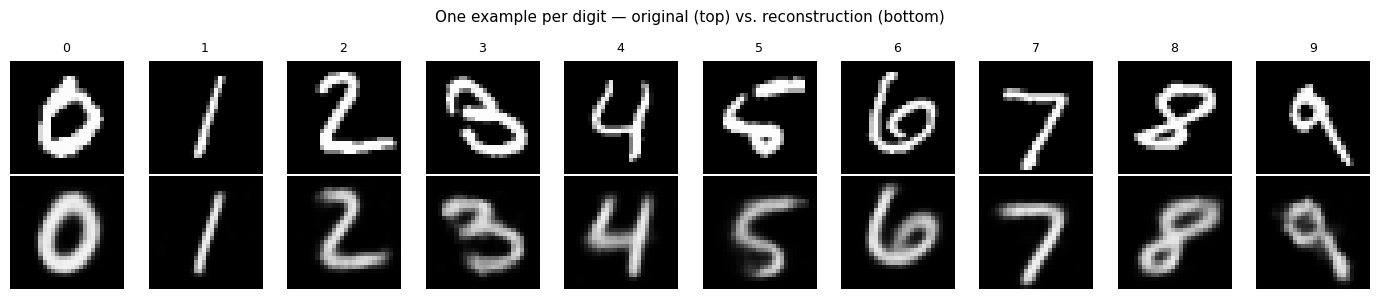

In [36]:
# Pick one example per digit class
samples = {}
for img, label in test_ds:
    if label not in samples:
        samples[label] = img
    if len(samples) == 10:
        break

originals = torch.stack([samples[i] for i in range(10)]).to(DEVICE)
with torch.no_grad():
    _, _, recons = ae(originals)

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    axes[0, i].imshow(originals[i].cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(str(i), fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(recons[i].cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=9)
axes[1, 0].set_ylabel("Reconstructed", fontsize=9)
fig.suptitle("One example per digit — original (top) vs. reconstruction (bottom)", fontsize=11)
plt.tight_layout()
plt.show()

## Latent space (μ values)

In [37]:
# If the latent space is 3D, we can visualize it directly with plotly
if LATENT_DIM == 3:
    import plotly.express as px
    
    all_latents = []
    all_labels = []
    with torch.no_grad():
        for x, y in test_loader:
            z, _, _ = ae(x.to(DEVICE))
            all_latents.append(z.cpu().numpy())
            all_labels.append(y.numpy())
    
    all_latents = np.concatenate(all_latents, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    fig = px.scatter_3d(
        x=all_latents[:, 0],
        y=all_latents[:, 1],
        z=all_latents[:, 2],
        color=all_labels.astype(str),
        title="3D Latent Space Visualization",
        labels={"color": "Digit Class"}
    )
    fig.update_traces(marker=dict(size=2))  # smaller dots
    fig.show()

## Latent space (PCA of μ values)

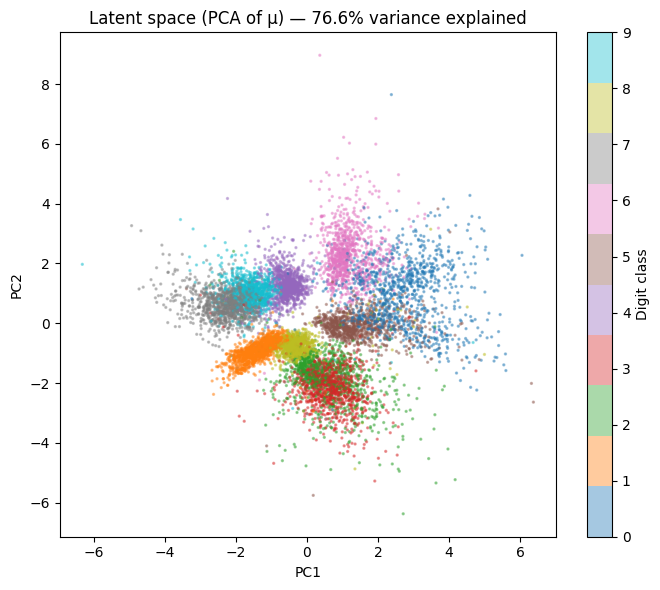

In [38]:
all_mu, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        mu, _, _ = ae(x.to(DEVICE))
        all_mu.append(mu.cpu())
        all_labels.append(y)

all_mu = torch.cat(all_mu).numpy()
all_labels = torch.cat(all_labels).numpy()

pca = PCA(n_components=2)
z2 = pca.fit_transform(all_mu)
var_explained = pca.explained_variance_ratio_.sum()

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(z2[:, 0], z2[:, 1], c=all_labels, cmap="tab10", s=2, alpha=0.4)
fig.colorbar(scatter, ax=ax, label="Digit class", ticks=range(10))
ax.set_xlabel(f"PC1")
ax.set_ylabel(f"PC2")
ax.set_title(f"Latent space (PCA of μ) — {var_explained*100:.1f}% variance explained")
plt.tight_layout()
plt.show()

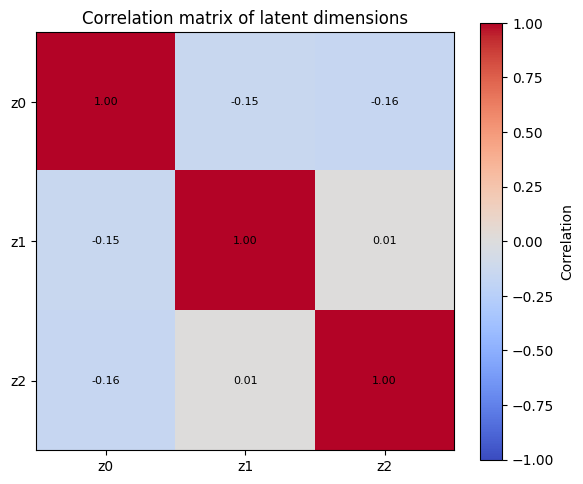

In [39]:
# Test if the dimensions are independent by looking at the correlation matrix of the latent means
correlation_matrix = np.corrcoef(all_mu, rowvar=False)
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
# write correlation values on the heatmap
for i in range(LATENT_DIM):
    for j in range(LATENT_DIM):
        ax.text(j, i, f"{correlation_matrix[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)
fig.colorbar(cax, ax=ax, label="Correlation")
ax.set_xticks(range(LATENT_DIM))
ax.set_yticks(range(LATENT_DIM))
ax.set_xticklabels([f"z{i}" for i in range(LATENT_DIM)])
ax.set_yticklabels([f"z{i}" for i in range(LATENT_DIM)])
ax.set_title("Correlation matrix of latent dimensions")
plt.tight_layout()
plt.show()